In [4]:
import pandas as pd, numpy as np
import torch as t, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchsummary import summary

import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import copy

In [5]:
device = t.device('cuda' if t.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [6]:
from google.colab import drive
drive.mount("/content/drive")

train_data = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/Classifier-Guided AE Pretraining/data', train = True, download = True, transform = T.ToTensor())
original_test_data = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/Classifier-Guided AE Pretraining/data', train = False, download = True, transform = T.ToTensor())

n = len(original_test_data)
indices = np.arange(n)
rng = np.random.default_rng(seed=0)
rng.shuffle(indices)

dev_indices = indices[:5000]
test_indices = indices[5000:]

dev_data = copy.deepcopy(original_test_data)
test_data = copy.deepcopy(original_test_data)

dev_data.data = original_test_data.data[dev_indices]
dev_data.targets = [original_test_data.targets[i] for i in dev_indices]

test_data.data = original_test_data.data[test_indices]
test_data.targets = [original_test_data.targets[i] for i in test_indices]

normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
train_loader = DataLoader(train_data, batch_size = 32, shuffle = True, drop_last = True)
dev_loader = DataLoader(dev_data, batch_size = 128, shuffle = False, drop_last = True)
test_loader = DataLoader(test_data, batch_size = 128, shuffle = False, drop_last = True)

In [ ]:
# @misc{chenyaofo_pytorch_cifar_models,
#   author       = {Yaofo Chen},
#   title        = {PyTorch CIFAR Models},
#   howpublished = {\url{https://github.com/chenyaofo/pytorch-cifar-models }},
#   note         = {Accessed: 2025-5-17},
#   abstract     = {This repository provides pretrained neural network models trained on CIFAR-10 and CIFAR-100 datasets, including ResNet, VGG, MobileNetV2, ShuffleNetV2, and RepVGG variants.}
# }

In [82]:
pretrained_model = t.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained = True, trust_repo = True)

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [83]:
#we freeze the pretrained model entirely
for p in pretrained_model.parameters():
  p.requires_grad = False

In [84]:
class NormClassifier(nn.Module):

  def __init__(self, model, transform):
      super().__init__()
      self.model = model
      self.transform = transform

  def forward(self, x):
      x = self.transform(x)
      return self.model(x)

In [85]:
model = NormClassifier(pretrained_model, normalize).to(device)
classifier_loss = nn.CrossEntropyLoss()

In [ ]:
model.eval()

correct = 0
total = 0

with t.no_grad():
    for X, y in dev_loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        predictions = logits.argmax(dim=1)

        correct += (predictions == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {100 * accuracy:.2f}%")

Test accuracy: 91.89%


In [80]:
def visualise_single_prediction(i, autoencoder=None):

    X, y = test_data[i]
    X = X.to(device)
    y = t.tensor([y], device=device)

    X = X.unsqueeze(0)

    model.eval()

    with t.no_grad():

        if autoencoder is not None:
            was_training = autoencoder.training
            autoencoder.eval()
            X = autoencoder(X)

            if was_training:
                autoencoder.train()

        logits = model(X)
        pred_idx = logits.argmax().item()
        prediction = test_data.classes[pred_idx]
        loss = classifier_loss(logits, y).item()

    print("Model predicts:", prediction)
    print("Evaluation:", ("Correct" if pred_idx == y.item() else "Wrong"))
    print(f"Loss: {loss:.4f}")

    image = X.squeeze(0).detach().permute(1, 2, 0).cpu()
    plt.imshow(image)
    plt.axis("off")
    plt.show()

Model predicts: dog
Evaluation: Correct
Loss: 0.4036


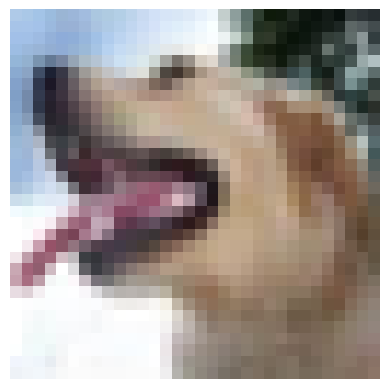

Model predicts: dog
Evaluation: Correct
Loss: 0.0462


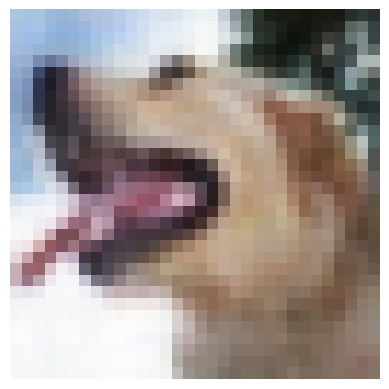

In [91]:
visualise_single_prediction(1)
visualise_single_prediction(1, autoencoder = autoencoder)

In [ ]:
visualise_single_prediction(4, autoencoder)

NameError: name 'autoencoder' is not defined

We have now imported a pretrained model with strong performance on CIFAR-10. We will investigate three different ways to train models.

First, we will train an autoencoder.

In [27]:
class ConvAutoencoder(nn.Module):

  def __init__(self, latent_channels = 64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size = 4, padding = 1, stride = 2),
            nn.ReLU(),
            #nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Conv2d(16, 32, kernel_size = 4, padding = 1, stride = 2),
            nn.ReLU(),
            #nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Conv2d(32, latent_channels, kernel_size = 4, padding = 1, stride = 2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 32, kernel_size = 4, stride = 2, padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size = 4, stride = 2, padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

  def encode(self, x):
        return self.encoder(x)

  def decode(self, z):
        return self.decoder(z)

  def forward(self, x):
      z = self.encode(x)
      reconstruction = self.decode(z)
      return reconstruction

In [ ]:
def train_autoencoder(num_epochs, autoencoder = None, loss_function = None, checkpoint_step = 1):

  #trains a naive autoencoder and records the states at various checkpoints

  if checkpoint_step < num_epochs:
    checkpoints = dict()
    checkpoint_times = iter(range(checkpoint_step, num_epochs + checkpoint_step, checkpoint_step))
    current_checkpoint_time = next(checkpoint_times)
  else:
    current_checkpoint_time = num_epochs

  if not loss_function:
    loss_function = nn.MSELoss()

  train_loss = t.zeros(num_epochs)
  #test_loss = t.zeros(num_epochs)
  N = len(train_loader)

  for epoch in range(num_epochs):

    autoencoder.train()

    total_loss = 0

    for X, _ in train_loader:

      X = X.to(device)
      out = autoencoder(X)
      loss = loss_function(out, X)

      optimiser.zero_grad()
      loss.backward()
      optimiser.step()

      total_loss += loss.item()


    avg_loss = total_loss/N
    train_loss[epoch] = avg_loss

    if epoch == current_checkpoint_time:
      checkpoints[epoch] = copy.deepcopy(autoencoder.state_dict())
      print(f"Saved checkpoint at epoch {epoch}.")
      current_checkpoint_time = next(checkpoint_times)


  checkpoints[num_epochs] = copy.deepcopy(autoencoder.state_dict())
  print(f"Saved checkpoint at epoch {num_epochs}.")

  return train_loss, checkpoints


In [ ]:
def loss_function(out, X):
  return F.mse_loss(out, X)

In [ ]:
autoencoder = ConvAutoencoder()
autoencoder = autoencoder.to(device)
optimiser = t.optim.Adam(autoencoder.parameters(),lr=.001)

num_epochs = 50
train_loss, checkpoints = train_autoencoder(num_epochs = num_epochs, autoencoder = autoencoder, loss_function = loss_function, checkpoint_step = 10)

Saved checkpoint at epoch 10.
Saved checkpoint at epoch 20.
Saved checkpoint at epoch 30.
Saved checkpoint at epoch 40.
Saved checkpoint at epoch 50.


In [ ]:
optimiser = t.optim.Adam(autoencoder.parameters(),lr=.001)

num_epochs = 50
train_loss, checkpoints = train_autoencoder(num_epochs = num_epochs, autoencoder = autoencoder, loss_function = loss_function, checkpoint_step = 10)

Saved checkpoint at epoch 10.
Saved checkpoint at epoch 20.
Saved checkpoint at epoch 30.
Saved checkpoint at epoch 40.
Saved checkpoint at epoch 50.


In [ ]:
print(train_loss)

tensor([0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005,
        0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0004, 0.0004, 0.0004,
        0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0005, 0.0004, 0.0004, 0.0004,
        0.0004, 0.0004, 0.0004, 0.0004, 0.0005, 0.0004, 0.0004, 0.0004, 0.0004,
        0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004,
        0.0004, 0.0004, 0.0004, 0.0004, 0.0004])


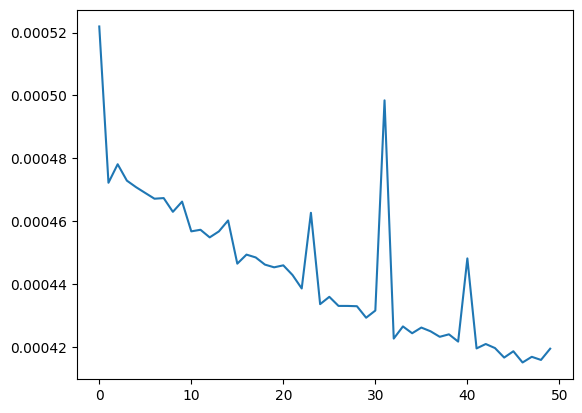

In [ ]:
plt.plot(range(num_epochs), train_loss)

With the above, we have a functional AE training loop. We now want to iterate the hyperparameters over the devset.

The first step is to evaluate on the devset.

We will use multiple evaluation measures for the autoencoder. The reconstruction loss, visual inspection, classifier accuracy (and confusion evaluated by class) and classifier cross-entropy loss. This is what is done immediately below. Later, we could also potentially look at classifier feature activations.

We will then train a CNN hooked up to the latent layer, and also try to train the same architecture from scratch.

In [ ]:
#this is the naive autoencoder trained previously

checkpoint = t.load('/content/drive/MyDrive/Classifier-Guided AE Pretraining/storage/conv_autoencoder_v1.pt', map_location=device)

autoencoder = ConvAutoencoder(
    latent_channels=checkpoint["latent_channels"]
)

autoencoder.load_state_dict(checkpoint["model_state_dict"])
autoencoder.to(device)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)

In [ ]:
#devset reconstruction loss
autoencoder.eval()
N = len(dev_loader)

total_dev_loss = 0

for X, _ in dev_loader:

  with t.no_grad():
    X = X.to(device)
    out = autoencoder(X)
    loss = loss_function(out, X)

    total_dev_loss += loss


avg_dev_loss = total_dev_loss/N
print(avg_dev_loss.item())

NameError: name 'autoencoder' is not defined

In [ ]:
def visualise_reconstructions(
    autoencoder,
    classifier=model,
    dataset=dev_data,
    n=8,
    indices=None,
    random=True,
    device=device,
    figsize=None
):

    # Store original training/eval modes so we can restore them afterwards
    autoencoder_was_training = autoencoder.training
    classifier_was_training = classifier.training

    autoencoder.eval()
    classifier.eval()

    if indices is None:
        if random:
            indices = np.random.choice(len(dataset), size=n, replace=False)
        else:
            indices = np.arange(n)
    else:
        n = len(indices)

    if figsize is None:
        figsize = (8, 3 * n)

    fig, axes = plt.subplots(n, 2, figsize=figsize)

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    with t.no_grad():

        for row, idx in enumerate(indices):

            X, y = dataset[idx]

            # Prepare batch
            X_batch = X.unsqueeze(0).to(device)          # [1, 3, 32, 32]
            y_batch = t.tensor([y], device=device)       # [1]

            # Autoencoder reconstruction
            reconstruction = autoencoder(X_batch)

            # Classifier predictions
            original_logits = classifier(X_batch)
            reconstruction_logits = classifier(reconstruction)

            original_pred_idx = original_logits.argmax(dim=1).item()
            reconstruction_pred_idx = reconstruction_logits.argmax(dim=1).item()

            original_pred = dataset.classes[original_pred_idx]
            reconstruction_pred = dataset.classes[reconstruction_pred_idx]
            true_label = dataset.classes[y]

            # Classifier losses
            original_loss = classifier_loss(original_logits, y_batch).item()
            reconstruction_loss_value = classifier_loss(
                reconstruction_logits,
                y_batch
            ).item()

            # Convert images for plotting: [1, 3, 32, 32] -> [32, 32, 3]
            original_img = X_batch.squeeze(0).permute(1, 2, 0).cpu()
            reconstructed_img = reconstruction.squeeze(0).permute(1, 2, 0).cpu()

            # Plot original
            axes[row, 0].imshow(original_img)
            axes[row, 0].set_title(
                f"Original\n"
                f"True: {true_label}\n"
                f"Pred: {original_pred}\n"
                f"Loss: {original_loss:.4f}"
            )
            axes[row, 0].axis("off")

            # Plot reconstruction
            axes[row, 1].imshow(reconstructed_img)
            axes[row, 1].set_title(
                f"Reconstruction\n"
                f"True: {true_label}\n"
                f"Classifier pred: {reconstruction_pred}\n"
                f"Classifier loss: {reconstruction_loss_value:.4f}"
            )
            axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

    # Restore previous modes
    if autoencoder_was_training:
        autoencoder.train()

    if classifier_was_training:
        classifier.train()

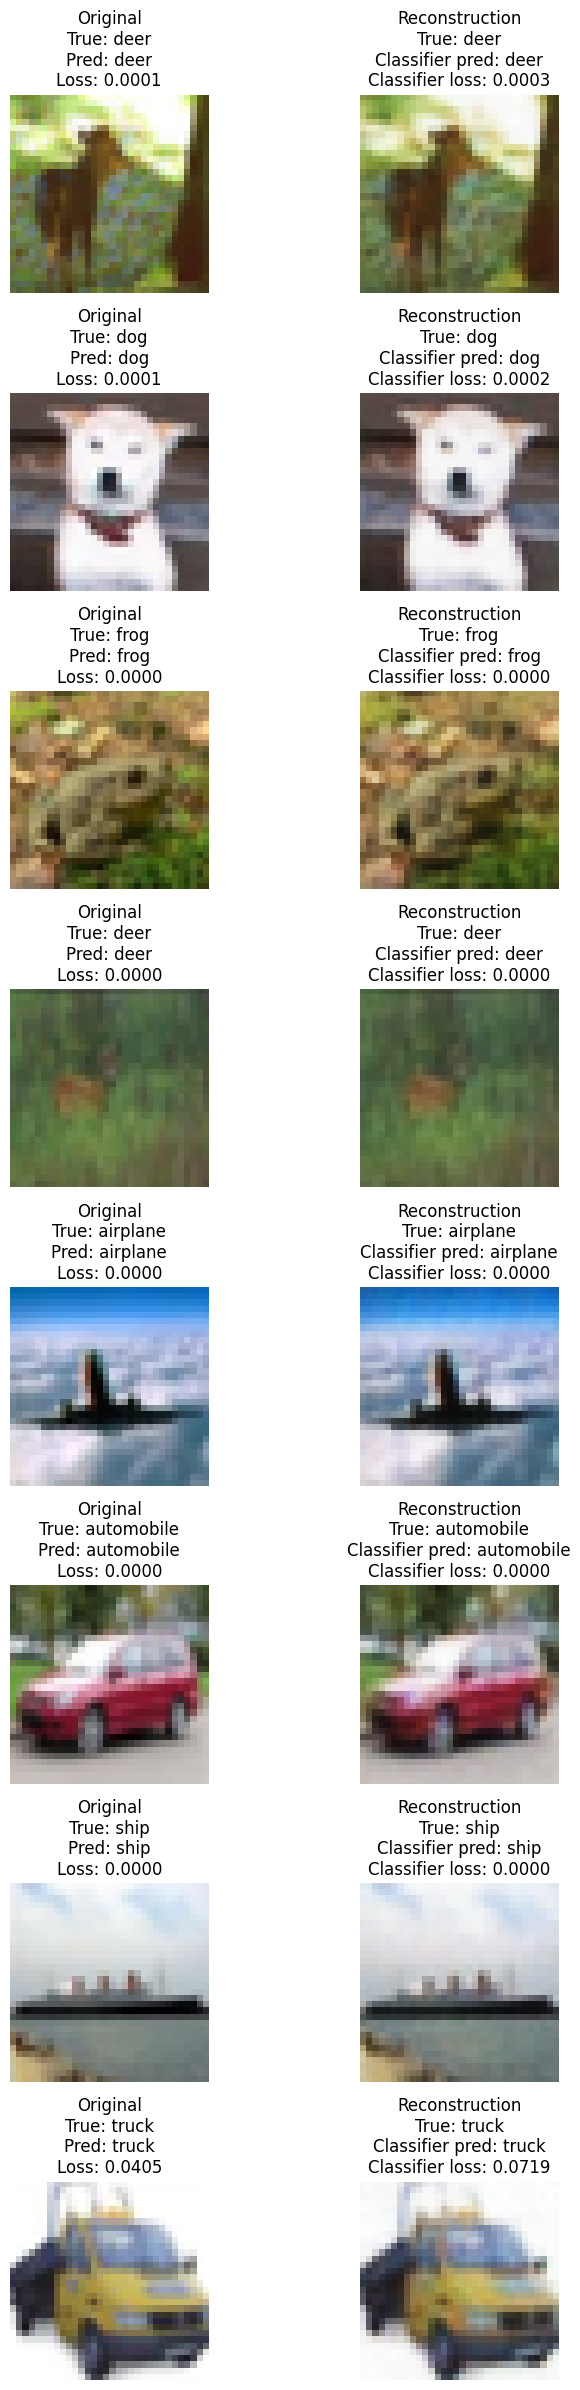

In [ ]:
visualise_reconstructions(autoencoder)

In [ ]:
def evaluate_autoencoder_classifier_effect(
    autoencoder,
    classifier=model,
    dataset=dev_data,
    batch_size=128,
    temperature=1.0,
    device=device
):
    """
    Evaluate how an autoencoder affects a frozen classifier's behaviour on a dataset.

    Computes:
      1. Classifier accuracy on reconstructed images, relative to ground-truth labels.
      2. Average classifier cross-entropy loss on reconstructed images, relative to ground-truth labels.
      3. Classifier consistency: percentage of examples where classifier prediction is unchanged
         after reconstruction.
      4. Average hard-label cross-entropy loss on reconstructed images, using the classifier's
         original predictions as pseudo-labels.
      5. Average temperature-scaled KL divergence between the classifier output distribution
         on original images and reconstructed images.

    KL divergence compares:

        classifier(original image)
        vs
        classifier(autoencoder(original image))

    using the full output distributions, not just the argmax prediction.
    """

    assert temperature > 0, "temperature must be positive"

    data_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    autoencoder_was_training = autoencoder.training
    classifier_was_training = classifier.training

    autoencoder.eval()
    classifier.eval()

    total_examples = 0

    reconstructed_correct = 0
    consistent_predictions = 0

    total_reconstructed_ground_truth_loss = 0.0
    total_reconstructed_original_prediction_loss = 0.0
    total_kl_divergence_loss = 0.0

    with t.no_grad():

        for X, y in data_loader:

            X = X.to(device)
            y = y.to(device)

            batch_size_actual = X.shape[0]
            total_examples += batch_size_actual

            # Classifier outputs on original images
            original_logits = classifier(X)
            original_predictions = original_logits.argmax(dim=1)

            # Reconstruct images with autoencoder
            reconstructed_X = autoencoder(X)

            # Classifier outputs on reconstructed images
            reconstructed_logits = classifier(reconstructed_X)
            reconstructed_predictions = reconstructed_logits.argmax(dim=1)

            # 1. Accuracy of classifier on reconstructed images vs ground truth
            reconstructed_correct += (
                reconstructed_predictions == y
            ).sum().item()

            # 2. CE loss on reconstructed images vs ground truth
            reconstructed_ground_truth_loss = classifier_loss(
                reconstructed_logits,
                y
            )

            total_reconstructed_ground_truth_loss += (
                reconstructed_ground_truth_loss.item() * batch_size_actual
            )

            # 3. Top-1 consistency before and after reconstruction
            consistent_predictions += (
                reconstructed_predictions == original_predictions
            ).sum().item()

            # 4. Hard-label CE loss:
            # reconstructed classifier logits vs original classifier argmax predictions
            reconstructed_original_prediction_loss = classifier_loss(
                reconstructed_logits,
                original_predictions
            )

            total_reconstructed_original_prediction_loss += (
                reconstructed_original_prediction_loss.item() * batch_size_actual
            )

            # 5. Soft distributional KL divergence:
            # original classifier distribution vs reconstructed classifier distribution
            T = temperature

            original_probs_T = F.softmax(original_logits / T, dim=1)
            reconstructed_log_probs_T = F.log_softmax(
                reconstructed_logits / T,
                dim=1
            )

            kl_divergence_loss = F.kl_div(
                reconstructed_log_probs_T,
                original_probs_T,
                reduction="batchmean"
            ) * (T ** 2)

            total_kl_divergence_loss += (
                kl_divergence_loss.item() * batch_size_actual
            )

    results = {
        "reconstructed_accuracy": reconstructed_correct / total_examples,
        "reconstructed_accuracy_percent": 100 * reconstructed_correct / total_examples,

        "reconstructed_ground_truth_ce_loss": (
            total_reconstructed_ground_truth_loss / total_examples
        ),

        "classifier_consistency": consistent_predictions / total_examples,
        "classifier_consistency_percent": 100 * consistent_predictions / total_examples,

        "reconstructed_original_prediction_ce_loss": (
            total_reconstructed_original_prediction_loss / total_examples
        ),

        "reconstructed_original_distribution_kl_loss": (
            total_kl_divergence_loss / total_examples
        ),

        "temperature": temperature
    }

    if autoencoder_was_training:
        autoencoder.train()

    if classifier_was_training:
        classifier.train()

    return results

In [ ]:
evaluate_autoencoder_classifier_effect(autoencoder)

{'reconstructed_accuracy': 0.8762,
 'reconstructed_accuracy_percent': 87.62,
 'reconstructed_ground_truth_ce_loss': 0.47961397285461427,
 'classifier_consistency': 0.9062,
 'classifier_consistency_percent': 90.62,
 'reconstructed_original_prediction_ce_loss': 0.29860313639640806,
 'reconstructed_original_distribution_kl_loss': 0.239225053024292,
 'temperature': 1.0}

In [ ]:
def confusion_matrix_for_classifier(
    classifier=model,
    autoencoder=None,
    dataset=dev_data,
    batch_size=128,
    device=device,
    normalize=False,
    plot=True,
    figsize=(8, 8)
):
    """
    Compute and optionally plot a confusion matrix for classifier predictions.

    If autoencoder is provided:
        classifier(autoencoder(X))

    If autoencoder is None:
        classifier(X)

    Rows correspond to true labels.
    Columns correspond to predicted labels.

    If normalize=True, each row is converted to proportions.
    """

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    classifier_was_training = classifier.training
    classifier.eval()

    if autoencoder is not None:
        autoencoder_was_training = autoencoder.training
        autoencoder.eval()
    else:
        autoencoder_was_training = None

    num_classes = len(dataset.classes)

    confusion = t.zeros(
        num_classes,
        num_classes,
        dtype=t.int64
    )

    with t.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            if autoencoder is not None:
                X_for_classifier = autoencoder(X)
            else:
                X_for_classifier = X

            logits = classifier(X_for_classifier)
            predictions = logits.argmax(dim=1)

            y_cpu = y.cpu()
            predictions_cpu = predictions.cpu()

            for true_label, predicted_label in zip(y_cpu, predictions_cpu):
                confusion[true_label, predicted_label] += 1

    if normalize:
        confusion_to_show = confusion.float()
        row_sums = confusion_to_show.sum(dim=1, keepdim=True)
        confusion_to_show = confusion_to_show / row_sums.clamp(min=1)
    else:
        confusion_to_show = confusion

    if plot:
        fig, ax = plt.subplots(figsize=figsize)

        im = ax.imshow(confusion_to_show, interpolation="nearest")
        plt.colorbar(im, ax=ax)

        ax.set_xticks(np.arange(num_classes))
        ax.set_yticks(np.arange(num_classes))

        ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
        ax.set_yticklabels(dataset.classes)

        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        if autoencoder is None:
            input_description = "raw images"
        else:
            input_description = "autoencoder-reconstructed images"

        if normalize:
            ax.set_title(f"Confusion matrix on {input_description}, row-normalized")
        else:
            ax.set_title(f"Confusion matrix on {input_description}")

        for i in range(num_classes):
            for j in range(num_classes):
                if normalize:
                    text = f"{confusion_to_show[i, j].item():.2f}"
                else:
                    text = str(confusion_to_show[i, j].item())

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center"
                )

        plt.tight_layout()
        plt.show()

    if classifier_was_training:
        classifier.train()

    if autoencoder is not None and autoencoder_was_training:
        autoencoder.train()

    return confusion

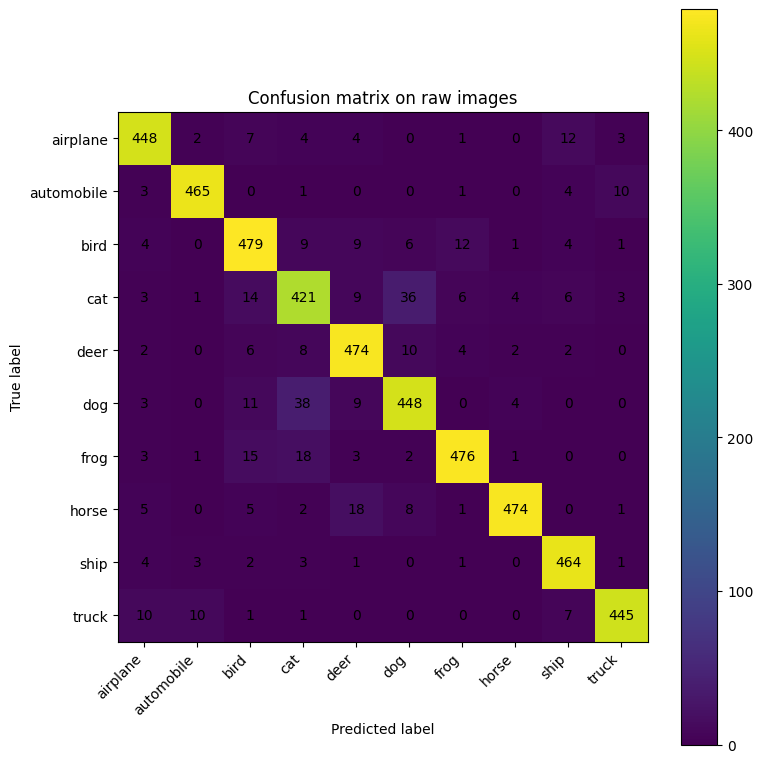

In [ ]:
confusion = confusion_matrix_for_classifier(
    normalize=False
)

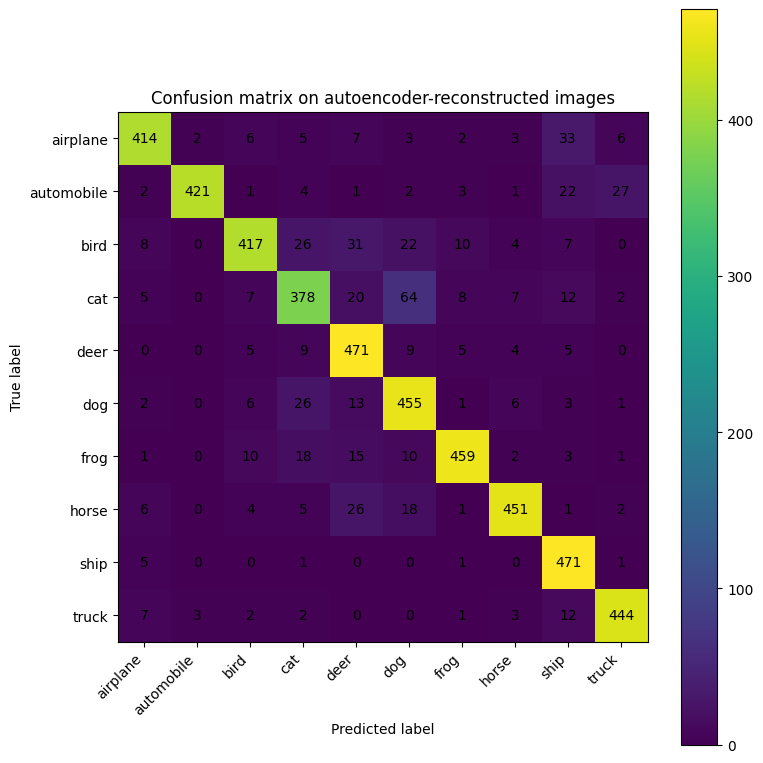

In [ ]:
confusion = confusion_matrix_for_classifier(
    autoencoder = autoencoder,
    normalize=False
)

In [ ]:
def classifier_consistency_by_category(
    autoencoder,
    classifier=model,
    dataset=dev_data,
    batch_size=128,
    device=device
):
    """
    Compute per-class classifier consistency between original and reconstructed images.

    For each true class:
        consistency = number of examples where
                      classifier(X) == classifier(autoencoder(X))
                      divided by total examples in that class

    This is different from accuracy:
        - accuracy compares predictions to ground-truth labels
        - consistency compares reconstructed-image predictions to original-image predictions
    """

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    autoencoder_was_training = autoencoder.training
    classifier_was_training = classifier.training

    autoencoder.eval()
    classifier.eval()

    num_classes = len(dataset.classes)

    consistent_by_class = t.zeros(num_classes, device=device)
    total_by_class = t.zeros(num_classes, device=device)

    with t.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            # Classifier predictions on raw images
            original_logits = classifier(X)
            original_predictions = original_logits.argmax(dim=1)

            # Classifier predictions on reconstructed images
            reconstructed_X = autoencoder(X)
            reconstructed_logits = classifier(reconstructed_X)
            reconstructed_predictions = reconstructed_logits.argmax(dim=1)

            same_prediction = reconstructed_predictions == original_predictions

            for class_idx in range(num_classes):

                class_mask = y == class_idx

                total_by_class[class_idx] += class_mask.sum()
                consistent_by_class[class_idx] += same_prediction[class_mask].sum()

    consistency = consistent_by_class / total_by_class.clamp(min=1)

    results = {}

    for class_idx, class_name in enumerate(dataset.classes):
        results[class_name] = {
            "consistent": int(consistent_by_class[class_idx].item()),
            "total": int(total_by_class[class_idx].item()),
            "consistency": consistency[class_idx].item(),
            "consistency_percent": 100 * consistency[class_idx].item()
        }

    if autoencoder_was_training:
        autoencoder.train()

    if classifier_was_training:
        classifier.train()

    return results

In [ ]:
consistency_results = classifier_consistency_by_category(autoencoder)
print(consistency_results)

{'airplane': {'consistent': 436, 'total': 481, 'consistency': 0.9064449071884155, 'consistency_percent': 90.64449071884155}, 'automobile': {'consistent': 434, 'total': 484, 'consistency': 0.8966942429542542, 'consistency_percent': 89.66942429542542}, 'bird': {'consistent': 448, 'total': 525, 'consistency': 0.8533333539962769, 'consistency_percent': 85.33333539962769}, 'cat': {'consistent': 420, 'total': 503, 'consistency': 0.8349900841712952, 'consistency_percent': 83.49900841712952}, 'deer': {'consistent': 468, 'total': 508, 'consistency': 0.9212598204612732, 'consistency_percent': 92.12598204612732}, 'dog': {'consistent': 468, 'total': 513, 'consistency': 0.9122806787490845, 'consistency_percent': 91.22806787490845}, 'frog': {'consistent': 466, 'total': 519, 'consistency': 0.8978805541992188, 'consistency_percent': 89.78805541992188}, 'horse': {'consistent': 475, 'total': 514, 'consistency': 0.924124538898468, 'consistency_percent': 92.4124538898468}, 'ship': {'consistent': 466, 'tot

In [ ]:
def classifier_prediction_change_breakdown(
    autoencoder,
    classifier=model,
    dataset=dev_data,
    batch_size=128,
    device=device
):
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    autoencoder_was_training = autoencoder.training
    classifier_was_training = classifier.training

    autoencoder.eval()
    classifier.eval()

    counts = {
        "preserved_correct": 0,
        "preserved_error": 0,
        "corrected_by_reconstruction": 0,
        "corrupted_by_reconstruction": 0,
        "changed_wrong_prediction": 0,
    }

    total = 0

    with t.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            original_logits = classifier(X)
            original_pred = original_logits.argmax(dim=1)

            X_recon = autoencoder(X)

            reconstructed_logits = classifier(X_recon)
            reconstructed_pred = reconstructed_logits.argmax(dim=1)

            original_correct = original_pred == y
            reconstructed_correct = reconstructed_pred == y
            consistent = original_pred == reconstructed_pred

            counts["preserved_correct"] += (
                consistent & original_correct
            ).sum().item()

            counts["preserved_error"] += (
                consistent & ~original_correct
            ).sum().item()

            counts["corrected_by_reconstruction"] += (
                ~consistent & ~original_correct & reconstructed_correct
            ).sum().item()

            counts["corrupted_by_reconstruction"] += (
                ~consistent & original_correct & ~reconstructed_correct
            ).sum().item()

            counts["changed_wrong_prediction"] += (
                ~consistent & ~original_correct & ~reconstructed_correct
            ).sum().item()

            total += X.shape[0]

    results = {}

    for key, value in counts.items():
        results[key] = {
            "count": value,
            "percent": 100 * value / total
        }

    results["total"] = total

    if autoencoder_was_training:
        autoencoder.train()

    if classifier_was_training:
        classifier.train()

    return results

In [ ]:
breakdown = classifier_prediction_change_breakdown(autoencoder)

for key, value in breakdown.items():
    print(key, value)

preserved_correct {'count': 4283, 'percent': 85.66}
preserved_error {'count': 248, 'percent': 4.96}
corrected_by_reconstruction {'count': 98, 'percent': 1.96}
corrupted_by_reconstruction {'count': 311, 'percent': 6.22}
changed_wrong_prediction {'count': 60, 'percent': 1.2}
total 5000


In [ ]:
def classifier_prediction_change_breakdown_by_category(
    autoencoder,
    classifier=model,
    dataset=dev_data,
    batch_size=128,
    device=device,
    as_dataframe=True
):
    """
    Compute per-category breakdown of how autoencoder reconstruction changes
    classifier predictions.

    For each example:

        y_true  = ground-truth label
        y_orig  = classifier prediction on original image
        y_recon = classifier prediction on reconstructed image

    Categories:

        preserved_correct:
            y_orig == y_recon == y_true

        preserved_error:
            y_orig == y_recon != y_true

        corrected_by_reconstruction:
            y_orig != y_true and y_recon == y_true

        corrupted_by_reconstruction:
            y_orig == y_true and y_recon != y_true

        changed_wrong_prediction:
            y_orig != y_true, y_recon != y_true, and y_orig != y_recon
    """

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    autoencoder_was_training = autoencoder.training
    classifier_was_training = classifier.training

    autoencoder.eval()
    classifier.eval()

    num_classes = len(dataset.classes)

    count_names = [
        "preserved_correct",
        "preserved_error",
        "corrected_by_reconstruction",
        "corrupted_by_reconstruction",
        "changed_wrong_prediction",
    ]

    counts = {
        name: t.zeros(num_classes, dtype=t.long, device=device)
        for name in count_names
    }

    totals = t.zeros(num_classes, dtype=t.long, device=device)

    with t.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            original_logits = classifier(X)
            original_pred = original_logits.argmax(dim=1)

            X_recon = autoencoder(X)

            reconstructed_logits = classifier(X_recon)
            reconstructed_pred = reconstructed_logits.argmax(dim=1)

            original_correct = original_pred == y
            reconstructed_correct = reconstructed_pred == y
            consistent = original_pred == reconstructed_pred

            masks = {
                "preserved_correct": (
                    consistent & original_correct
                ),

                "preserved_error": (
                    consistent & ~original_correct
                ),

                "corrected_by_reconstruction": (
                    ~consistent & ~original_correct & reconstructed_correct
                ),

                "corrupted_by_reconstruction": (
                    ~consistent & original_correct & ~reconstructed_correct
                ),

                "changed_wrong_prediction": (
                    ~consistent & ~original_correct & ~reconstructed_correct
                ),
            }

            for class_idx in range(num_classes):

                class_mask = y == class_idx
                totals[class_idx] += class_mask.sum()

                for name in count_names:
                    counts[name][class_idx] += (
                        masks[name] & class_mask
                    ).sum()

    results = {}

    for class_idx, class_name in enumerate(dataset.classes):

        class_total = totals[class_idx].item()

        class_results = {
            "total": class_total
        }

        for name in count_names:
            count = counts[name][class_idx].item()

            class_results[f"{name}_count"] = count
            class_results[f"{name}_percent"] = (
                100 * count / class_total if class_total > 0 else 0.0
            )

        # Helpful summary metrics
        initially_correct = (
            counts["preserved_correct"][class_idx]
            + counts["corrupted_by_reconstruction"][class_idx]
        ).item()

        reconstructed_correct = (
            counts["preserved_correct"][class_idx]
            + counts["corrected_by_reconstruction"][class_idx]
        ).item()

        changed_prediction = (
            counts["corrected_by_reconstruction"][class_idx]
            + counts["corrupted_by_reconstruction"][class_idx]
            + counts["changed_wrong_prediction"][class_idx]
        ).item()

        class_results["original_accuracy_percent"] = (
            100 * initially_correct / class_total if class_total > 0 else 0.0
        )

        class_results["reconstructed_accuracy_percent"] = (
            100 * reconstructed_correct / class_total if class_total > 0 else 0.0
        )

        class_results["consistency_percent"] = (
            100 * (
                counts["preserved_correct"][class_idx]
                + counts["preserved_error"][class_idx]
            ).item() / class_total if class_total > 0 else 0.0
        )

        class_results["prediction_changed_percent"] = (
            100 * changed_prediction / class_total if class_total > 0 else 0.0
        )

        class_results["net_accuracy_change_percent"] = (
            class_results["reconstructed_accuracy_percent"]
            - class_results["original_accuracy_percent"]
        )

        results[class_name] = class_results

    if autoencoder_was_training:
        autoencoder.train()

    if classifier_was_training:
        classifier.train()

    if as_dataframe:
        import pandas as pd
        return pd.DataFrame.from_dict(results, orient="index")

    return results

In [ ]:
breakdown_by_class = classifier_prediction_change_breakdown_by_category(
    autoencoder,
    as_dataframe=True
)

breakdown_by_class

,total,preserved_correct_count,preserved_correct_percent,preserved_error_count,preserved_error_percent,corrected_by_reconstruction_count,corrected_by_reconstruction_percent,corrupted_by_reconstruction_count,corrupted_by_reconstruction_percent,changed_wrong_prediction_count,changed_wrong_prediction_percent,original_accuracy_percent,reconstructed_accuracy_percent,consistency_percent,prediction_changed_percent,net_accuracy_change_percent
airplane,481,411,85.446985,25,5.197505,3,0.623701,37,7.692308,5,1.039501,93.139293,86.070686,90.644491,9.355509,-7.068607
automobile,484,420,86.776860,14,2.892562,1,0.206612,45,9.297521,4,0.826446,96.074380,86.983471,89.669421,10.330579,-9.090909
bird,525,414,78.857143,34,6.476190,3,0.571429,65,12.380952,9,1.714286,91.238095,79.428571,85.333333,14.666667,-11.809524
cat,503,365,72.564612,55,10.934394,13,2.584493,56,11.133201,14,2.783300,83.697813,75.149105,83.499006,16.500994,-8.548708
deer,508,454,89.370079,14,2.755906,17,3.346457,20,3.937008,3,0.590551,93.307087,92.716535,92.125984,7.874016,-0.590551
dog,513,433,84.405458,35,6.822612,22,4.288499,15,2.923977,8,1.559454,87.329435,88.693957,91.228070,8.771930,1.364522
frog,519,444,85.549133,22,4.238921,15,2.890173,32,6.165703,6,1.156069,91.714836,88.439306,89.788054,10.211946,-3.275530
horse,514,446,86.770428,29,5.642023,5,0.972763,28,5.447471,6,1.167315,92.217899,87.743191,92.412451,7.587549,-4.474708
ship,479,461,96.242171,5,1.043841,10,2.087683,3,0.626305,0,0.000000,96.868476,98.329854,97.286013,2.713987,1.461378
truck,474,435,91.772152,15,3.164557,9,1.898734,10,2.109705,5,1.054852,93.881857,93.670886,94.936709,5.063291,-0.210970


In [ ]:
breakdown_by_class.filter(like='percent')

,preserved_correct_percent,preserved_error_percent,corrected_by_reconstruction_percent,corrupted_by_reconstruction_percent,changed_wrong_prediction_percent,original_accuracy_percent,reconstructed_accuracy_percent,consistency_percent,prediction_changed_percent,net_accuracy_change_percent
airplane,85.446985,5.197505,0.623701,7.692308,1.039501,93.139293,86.070686,90.644491,9.355509,-7.068607
automobile,86.776860,2.892562,0.206612,9.297521,0.826446,96.074380,86.983471,89.669421,10.330579,-9.090909
bird,78.857143,6.476190,0.571429,12.380952,1.714286,91.238095,79.428571,85.333333,14.666667,-11.809524
cat,72.564612,10.934394,2.584493,11.133201,2.783300,83.697813,75.149105,83.499006,16.500994,-8.548708
deer,89.370079,2.755906,3.346457,3.937008,0.590551,93.307087,92.716535,92.125984,7.874016,-0.590551
dog,84.405458,6.822612,4.288499,2.923977,1.559454,87.329435,88.693957,91.228070,8.771930,1.364522
frog,85.549133,4.238921,2.890173,6.165703,1.156069,91.714836,88.439306,89.788054,10.211946,-3.275530
horse,86.770428,5.642023,0.972763,5.447471,1.167315,92.217899,87.743191,92.412451,7.587549,-4.474708
ship,96.242171,1.043841,2.087683,0.626305,0.000000,96.868476,98.329854,97.286013,2.713987,1.461378
truck,91.772152,3.164557,1.898734,2.109705,1.054852,93.881857,93.670886,94.936709,5.063291,-0.210970


We will now train the classifier-guided model and evaluate its performance on many of the same metrics.

We will use the test set to evaluate both the classifier-guided model and re-evaluate the naive autoencoder.

In [ ]:
def linear_ramp_classifier_schedule(
    epoch,
    num_epochs,
    recon_weight=1.0,
    max_classifier_weight=0.05,
    warmup_epochs=20
):
    """
    Keep reconstruction weight fixed.
    Linearly ramp classifier weight from 0 to max_classifier_weight after warmup.
    """

    if epoch <= warmup_epochs:
        classifier_weight = 0.0
    else:
        progress = 1 - ((epoch - warmup_epochs) / max(1, num_epochs - warmup_epochs))
        classifier_weight = max_classifier_weight * progress

    return recon_weight, classifier_weight

def constant_classifier_schedule(epoch, num_epochs):
    return 1.0, 1.0

In [ ]:
def train_classifier_guided_autoencoder(
    num_epochs,
    autoencoder=None,
    loss_function=None,
    optimiser=None,
    classifier=model,
    classifier_loss_type="kl",
    schedule_function=None,
    checkpoint_step=1,
    temperature=1.0
):
    """
    Trains a classifier-guided autoencoder and records states at checkpoints.

    The total loss is:

        total_loss = recon_weight * reconstruction_loss
                   + classifier_weight * classifier_loss

    classifier_loss_type options:

        "ground_truth_ce":
            classifier(autoencoder(X)) compared to true labels y

        "hard_teacher_ce":
            classifier(autoencoder(X)) compared to classifier(X).argmax()

        "kl":
            classifier(autoencoder(X)) distribution compared to classifier(X) distribution

    schedule_function should take:

        schedule_function(epoch, num_epochs)

    and return:

        recon_weight, classifier_weight
    """

    if autoencoder is None:
        autoencoder = ConvAutoencoder().to(device)

    if loss_function is None:
        loss_function = nn.MSELoss()

    if optimiser is None:
        optimiser = t.optim.Adam(autoencoder.parameters(), lr=1e-3)

    if schedule_function is None:
        schedule_function = constant_classifier_schedule

    checkpoints = dict()
    if checkpoint_step < num_epochs:
        checkpoint_times = iter(
            range(checkpoint_step, num_epochs + checkpoint_step, checkpoint_step)
        )
        current_checkpoint_time = next(checkpoint_times)
    else:
        current_checkpoint_time = num_epochs + 1

    train_loss = t.zeros(num_epochs)
    recon_losses = t.zeros(num_epochs)
    classifier_losses = t.zeros(num_epochs)
    recon_weights = t.zeros(num_epochs)
    classifier_weights = t.zeros(num_epochs)

    N = len(train_loader)

    autoencoder.to(device)
    classifier.to(device)

    # Freeze classifier parameters.
    # Important: we still need gradients through classifier(X_recon),
    # so we do NOT use no_grad around classifier(X_recon).
    for param in classifier.parameters():
        param.requires_grad = False

    classifier.eval()

    for epoch in range(num_epochs):

        epoch_num = epoch + 1

        autoencoder.train()
        classifier.eval()

        recon_weight, classifier_weight = schedule_function(
            epoch_num,
            num_epochs
        )

        total_loss = 0
        total_recon_loss = 0
        total_classifier_loss = 0

        for X, y in train_loader:

            X = X.to(device)
            y = y.to(device)

            out = autoencoder(X)

            reconstruction_loss = loss_function(out, X)

            reconstructed_logits = classifier(out)

            if classifier_loss_type == "ground_truth_ce":

                classifier_loss = nn.functional.cross_entropy(
                    reconstructed_logits,
                    y
                )

            elif classifier_loss_type == "hard_teacher_ce":

                with t.no_grad():
                    original_logits = classifier(X)
                    original_predictions = original_logits.argmax(dim=1)

                classifier_loss = nn.functional.cross_entropy(
                    reconstructed_logits,
                    original_predictions
                )

            elif classifier_loss_type == "kl":

                T = temperature

                with t.no_grad():
                    original_logits = classifier(X)
                    original_probs = nn.functional.softmax(
                        original_logits / T,
                        dim=1
                    )

                reconstructed_log_probs = nn.functional.log_softmax(
                    reconstructed_logits / T,
                    dim=1
                )

                classifier_loss = nn.functional.kl_div(
                    reconstructed_log_probs,
                    original_probs,
                    reduction="batchmean"
                ) * (T ** 2)

            else:
                raise ValueError(
                    "classifier_loss_type must be one of "
                    "'ground_truth_ce', 'hard_teacher_ce', or 'kl'"
                )

            loss = (
                recon_weight * reconstruction_loss
                + classifier_weight * classifier_loss
            )

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            total_loss += loss.item()
            total_recon_loss += reconstruction_loss.item()
            total_classifier_loss += classifier_loss.item()

        avg_loss = total_loss / N
        avg_recon_loss = total_recon_loss / N
        avg_classifier_loss = total_classifier_loss / N

        train_loss[epoch] = avg_loss
        recon_losses[epoch] = avg_recon_loss
        classifier_losses[epoch] = avg_classifier_loss
        recon_weights[epoch] = recon_weight
        classifier_weights[epoch] = classifier_weight

        print(
            f"Epoch {epoch_num}: "
            f"loss={avg_loss:.4f}, "
            f"recon={avg_recon_loss:.4f}, "
            f"classifier={avg_classifier_loss:.4f}, "
            f"weights=({recon_weight:.3f}, {classifier_weight:.3f})"
        )

        if epoch_num == current_checkpoint_time:
            checkpoints[epoch_num] = copy.deepcopy(autoencoder.state_dict())
            print(f"Saved checkpoint at epoch {epoch_num}.")

            try:
                current_checkpoint_time = next(checkpoint_times)
            except StopIteration:
                current_checkpoint_time = None

    if num_epochs not in checkpoints:
        checkpoints[num_epochs] = copy.deepcopy(autoencoder.state_dict())
        print(f"Saved checkpoint at epoch {num_epochs}.")

    loss_history = {
        "total_loss": train_loss,
        "reconstruction_loss": recon_losses,
        "classifier_loss": classifier_losses,
        "reconstruction_weight": recon_weights,
        "classifier_weight": classifier_weights,
    }

    return loss_history, checkpoints

In [ ]:
def training_block(num_epochs, max_classifier_weight, warmup_epochs, lr, weight_decay, classifier_loss_type):

  optimiser = t.optim.Adam(autoencoder.parameters(), lr=lr, weight_decay=weight_decay)

  def schedule(epoch, _num_epochs):
    return linear_ramp_classifier_schedule(
      epoch,
      _num_epochs,
      recon_weight=1.0,


      max_classifier_weight=max_classifier_weight,
      warmup_epochs=0
  )

  loss_history, checkpoints = train_classifier_guided_autoencoder(
      num_epochs=num_epochs,
      autoencoder=autoencoder,
      loss_function=nn.MSELoss(),
      optimiser=optimiser,
      classifier=model,
      classifier_loss_type=classifier_loss_type,
      schedule_function=schedule,
      checkpoint_step=10,
      temperature=1.0
)

  return loss_history, checkpoints

In [ ]:
autoencoder = ConvAutoencoder()
autoencoder.to(device)

_, checkpoints1 = training_block(num_epochs=6,
                                 max_classifier_weight=0,
                                 warmup_epochs=0,
                                 lr=1e-3,
                                 weight_decay=0,
                                 classifier_loss_type="ground_truth_ce")
_, checkpoints2 = training_block(num_epochs=9,
                                 max_classifier_weight=0.0015,
                                 warmup_epochs=0,
                                 lr=1.5e-4,
                                 weight_decay=5e-7,
                                 classifier_loss_type="ground_truth_ce")
_, checkpoints3 = training_block(num_epochs=15,
                                 max_classifier_weight=0,
                                 warmup_epochs=0,
                                 lr=1e-3,
                                 weight_decay=5e-7,
                                 classifier_loss_type="ground_truth_ce")
_, checkpoints4 = training_block(num_epochs=5,
                                 max_classifier_weight=5e-5,
                                 warmup_epochs=0,
                                 lr=1.5e-4,
                                 weight_decay=5e-7,
                                 classifier_loss_type="ground_truth_ce")
_, checkpoints5 = training_block(num_epochs=15,
                                 max_classifier_weight=0,
                                 warmup_epochs=0,
                                 lr=1e-3,
                                 weight_decay=5e-7,
                                 classifier_loss_type="ground_truth_ce")

Epoch 1: loss=0.0100, recon=0.0100, classifier=5.8812, weights=(1.000, 0.000)
Epoch 2: loss=0.0037, recon=0.0037, classifier=4.1303, weights=(1.000, 0.000)
Epoch 3: loss=0.0029, recon=0.0029, classifier=4.0224, weights=(1.000, 0.000)
Epoch 4: loss=0.0024, recon=0.0024, classifier=3.3813, weights=(1.000, 0.000)
Epoch 5: loss=0.0019, recon=0.0019, classifier=2.1926, weights=(1.000, 0.000)
Epoch 6: loss=0.0016, recon=0.0016, classifier=1.5756, weights=(1.000, 0.000)
Saved checkpoint at epoch 6.
Epoch 1: loss=0.0031, recon=0.0018, classifier=0.9092, weights=(1.000, 0.001)
Epoch 2: loss=0.0027, recon=0.0018, classifier=0.7582, weights=(1.000, 0.001)
Epoch 3: loss=0.0024, recon=0.0017, classifier=0.6950, weights=(1.000, 0.001)
Epoch 4: loss=0.0023, recon=0.0017, classifier=0.6616, weights=(1.000, 0.001)
Epoch 5: loss=0.0021, recon=0.0016, classifier=0.6327, weights=(1.000, 0.001)
Epoch 6: loss=0.0019, recon=0.0016, classifier=0.6139, weights=(1.000, 0.001)
Epoch 7: loss=0.0017, recon=0.0015,

In [ ]:
def loss_function(out, X):
  return F.mse_loss(out, X)

In [ ]:
#devset reconstruction loss
autoencoder.eval()
N = len(dev_loader)

total_dev_loss = 0

for X, _ in dev_loader:

  with t.no_grad():
    X = X.to(device)
    out = autoencoder(X)
    loss = loss_function(out, X)

    total_dev_loss += loss


avg_dev_loss = total_dev_loss/N
print(avg_dev_loss.item())

0.0004933304153382778


In [ ]:
consistency_results = classifier_consistency_by_category(autoencoder)
print(consistency_results)

breakdown = classifier_prediction_change_breakdown(autoencoder)

for key, value in breakdown.items():
    print(key, value)

{'airplane': {'consistent': 424, 'total': 481, 'consistency': 0.8814969062805176, 'consistency_percent': 88.14969062805176}, 'automobile': {'consistent': 434, 'total': 484, 'consistency': 0.8966942429542542, 'consistency_percent': 89.66942429542542}, 'bird': {'consistent': 437, 'total': 525, 'consistency': 0.8323809504508972, 'consistency_percent': 83.23809504508972}, 'cat': {'consistent': 426, 'total': 503, 'consistency': 0.8469184637069702, 'consistency_percent': 84.69184637069702}, 'deer': {'consistent': 475, 'total': 508, 'consistency': 0.9350393414497375, 'consistency_percent': 93.50393414497375}, 'dog': {'consistent': 463, 'total': 513, 'consistency': 0.9025341272354126, 'consistency_percent': 90.25341272354126}, 'frog': {'consistent': 456, 'total': 519, 'consistency': 0.8786126971244812, 'consistency_percent': 87.86126971244812}, 'horse': {'consistent': 473, 'total': 514, 'consistency': 0.9202334880828857, 'consistency_percent': 92.02334880828857}, 'ship': {'consistent': 466, 't

In [ ]:
evaluate_autoencoder_classifier_effect(autoencoder)

{'reconstructed_accuracy': 0.8748,
 'reconstructed_accuracy_percent': 87.48,
 'reconstructed_ground_truth_ce_loss': 0.505961964559555,
 'classifier_consistency': 0.9002,
 'classifier_consistency_percent': 90.02,
 'reconstructed_original_prediction_ce_loss': 0.32822021931409834,
 'reconstructed_original_distribution_kl_loss': 0.26986750868558884,
 'temperature': 1.0}

In [ ]:
checkpoint = {
    "model_state_dict": autoencoder.state_dict(),
    "latent_channels": 64,
    "architecture": "ConvAutoencoder",
    "epoch": 50,
    "notes": "classifier-guided AE"
}

t.save(
    checkpoint,
    "/content/drive/MyDrive/Classifier-Guided AE Pretraining/storage/conv_autoencoder_guided_v2.pt"
)

I now investigate whether a classifier consisting of an encoder along with the classifier head works better if trained in full, or with the classifier head trained with a pretrained encoder.

In [74]:
class ConvEncoderClassifier(nn.Module):
    def __init__(self, num_classes, latent_channels=64, hidden_dim=64, dropout=0.1):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=4, padding=1, stride=2),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=4, padding=1, stride=2),
            nn.ReLU(),

            nn.Conv2d(32, latent_channels, kernel_size=4, padding=1, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(latent_channels, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encode(x)
        logits = self.classifier(z)
        return logits

In [59]:
normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

In [58]:
def train_classifier(
    num_epochs,
    classifier,
    optimiser,
    train_loader=train_loader,
    device=device,
    loss_function=None,
    checkpoint_step=1
):

    if loss_function is None:
        loss_function = nn.CrossEntropyLoss()

    checkpoints = dict()
    train_loss = t.zeros(num_epochs)

    N = len(train_loader)

    for epoch in range(num_epochs):

        classifier.train()
        total_loss = 0

        for X, y in train_loader:

            X = X.to(device)
            y = y.to(device)

            X = normalize(X)
            logits = classifier(X)
            loss = loss_function(logits, y)

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            total_loss += loss.item()

        avg_loss = total_loss / N
        train_loss[epoch] = avg_loss

        epoch_num = epoch + 1

        print(f"Epoch {epoch_num}/{num_epochs}, training loss: {avg_loss:.4f}")

        if epoch_num % checkpoint_step == 0:
            checkpoints[epoch_num] = copy.deepcopy(classifier.state_dict())
            print(f"Saved checkpoint at epoch {epoch_num}.")

    if num_epochs not in checkpoints:
        checkpoints[num_epochs] = copy.deepcopy(classifier.state_dict())
        print(f"Saved checkpoint at epoch {num_epochs}.")

    return train_loss, checkpoints

In [75]:
classifier = ConvEncoderClassifier(num_classes=10).to(device)
optimiser = t.optim.Adam(classifier.parameters(), lr=1e-3, weight_decay = 1e-4)

train_loss, checkpoints = train_classifier(
    num_epochs=50,
    classifier=classifier,
    optimiser=optimiser,
    checkpoint_step=10
)

Epoch 1/50, training loss: 1.7416
Epoch 2/50, training loss: 1.4626
Epoch 3/50, training loss: 1.3492
Epoch 4/50, training loss: 1.2758
Epoch 5/50, training loss: 1.2196
Epoch 6/50, training loss: 1.1766
Epoch 7/50, training loss: 1.1388
Epoch 8/50, training loss: 1.1144
Epoch 9/50, training loss: 1.0940
Epoch 10/50, training loss: 1.0699
Saved checkpoint at epoch 10.
Epoch 11/50, training loss: 1.0500
Epoch 12/50, training loss: 1.0355
Epoch 13/50, training loss: 1.0157
Epoch 14/50, training loss: 1.0069
Epoch 15/50, training loss: 0.9928
Epoch 16/50, training loss: 0.9816
Epoch 17/50, training loss: 0.9673
Epoch 18/50, training loss: 0.9583
Epoch 19/50, training loss: 0.9513
Epoch 20/50, training loss: 0.9381
Saved checkpoint at epoch 20.
Epoch 21/50, training loss: 0.9323
Epoch 22/50, training loss: 0.9241
Epoch 23/50, training loss: 0.9108
Epoch 24/50, training loss: 0.9080
Epoch 25/50, training loss: 0.8956
Epoch 26/50, training loss: 0.8911
Epoch 27/50, training loss: 0.8852
Epoc

In [76]:
def test_classifier(
    classifier,
    test_loader,
    device=device,
    loss_function=None
):

    if loss_function is None:
        loss_function = nn.CrossEntropyLoss()

    classifier.eval()

    total_loss = 0
    correct = 0
    total = 0

    N = len(dev_loader)

    with t.no_grad():

        for X, y in dev_loader:

            X = X.to(device)
            y = y.to(device)
            X = normalize(X)
            logits = classifier(X)
            loss = loss_function(logits, y)

            total_loss += loss.item()

            predictions = t.argmax(logits, dim=1)

            correct += (predictions == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / N
    accuracy = correct / total

    print(f"Test loss: {avg_loss:.4f}")
    print(f"Test accuracy: {accuracy:.4f}")

    return avg_loss, accuracy

In [77]:
test_classifier(classifier, dev_loader) #testing on dev_loader

Test loss: 1.0525
Test accuracy: 0.6400


(1.0524999147806413, 0.6400240384615384)

In [70]:
#this is again the naive autoencoder which performed very well

checkpoint = t.load('/content/drive/MyDrive/Classifier-Guided AE Pretraining/storage/conv_autoencoder_v1.pt', map_location=device)

autoencoder = ConvAutoencoder(
    latent_channels=checkpoint["latent_channels"]
)

autoencoder.load_state_dict(checkpoint["model_state_dict"])
autoencoder.to(device)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)

In [68]:
classifier_2 = ConvEncoderClassifier(
    num_classes=10,
    latent_channels=checkpoint["latent_channels"],
    hidden_dim=64,
    dropout=0.1
).to(device)

classifier_2.encoder.load_state_dict(autoencoder.encoder.state_dict())

for param in classifier_2.encoder.parameters():
    param.requires_grad = False

optimiser = t.optim.Adam(
    classifier_2.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [69]:
train_loss, checkpoints = train_classifier(
    num_epochs=50,
    classifier=classifier_2,
    optimiser=optimiser,
    checkpoint_step=10
)

Epoch 1/50, training loss: 1.9193
Epoch 2/50, training loss: 1.8018
Epoch 3/50, training loss: 1.7696
Epoch 4/50, training loss: 1.7519
Epoch 5/50, training loss: 1.7406
Epoch 6/50, training loss: 1.7320
Epoch 7/50, training loss: 1.7211
Epoch 8/50, training loss: 1.7169
Epoch 9/50, training loss: 1.7109
Epoch 10/50, training loss: 1.7064
Saved checkpoint at epoch 10.
Epoch 11/50, training loss: 1.7013
Epoch 12/50, training loss: 1.6957
Epoch 13/50, training loss: 1.6935
Epoch 14/50, training loss: 1.6889
Epoch 15/50, training loss: 1.6877
Epoch 16/50, training loss: 1.6855
Epoch 17/50, training loss: 1.6790
Epoch 18/50, training loss: 1.6806
Epoch 19/50, training loss: 1.6784
Epoch 20/50, training loss: 1.6750
Saved checkpoint at epoch 20.
Epoch 21/50, training loss: 1.6734
Epoch 22/50, training loss: 1.6713
Epoch 23/50, training loss: 1.6675
Epoch 24/50, training loss: 1.6693
Epoch 25/50, training loss: 1.6662
Epoch 26/50, training loss: 1.6649
Epoch 27/50, training loss: 1.6613
Epoc

In [73]:
test_classifier(classifier_2, dev_loader) #testing on dev_loader

Test loss: 1.6531
Test accuracy: 0.3886


(1.6530758631535065, 0.3886217948717949)